# Qiskit vs. PennyLane
### Synthesis & Side-by-Side Comparison, Quantum Computing Education Series by Trinexis

---

**This is the capstone of the software-ecosystem session.** You have now met both
frameworks in depth:

- **Qiskit** (`Qiskit_Introduction_Hands_On.ipynb`), the circuit-first framework built
  around real IBM hardware access, with the `Sampler`/`Estimator` primitives and a
  transpiler that targets native device gate sets.
- **PennyLane** (`PennyLane_Introduction_Hands_On.ipynb`), the differentiable-programming
  framework built around the `QNode`, with automatic differentiation as its signature
  feature.

Here we put them **side by side on identical tasks**, not a slide of bullet points, but
running code that proves the claims.

### What you will see
1. The **same circuit** (Bell, then GHZ) expressed in both languages.
2. The **same optimisation task**, trained two different ways, and a numerical proof
   that both land on the *exact same answer*.
3. A **deepened comparison table** covering everything from both notebooks.
4. A practical **decision framework**: which tool, for which job.
5. Two short **exercises** to practise the comparison yourself.


## 0  Setup


In [1]:
# --- Install dependencies only if they are missing ---------------------------
import importlib, subprocess, sys

for package in ["qiskit", "pennylane", "pylatexenc"]:
    if importlib.util.find_spec(package) is None:
        print(f"Installing {package} ...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", package])
    else:
        print(f"{package} already available.")


Installing qiskit ...
Installing pennylane ...
Installing pylatexenc ...


In [2]:
import numpy as np
import matplotlib.pyplot as plt

import qiskit
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.quantum_info import Statevector, SparsePauliOp
from qiskit.primitives import StatevectorEstimator

import pennylane as qml
from pennylane import numpy as pnp

np.random.seed(42)

print("Qiskit version:    ", qiskit.__version__)
print("PennyLane version: ", qml.__version__)


Qiskit version:     2.5.0
PennyLane version:  0.45.1


## 1  Same circuit, two languages: Bell and GHZ states

Both frameworks describe the *identical* physical circuit; only the syntax differs.


In [3]:
# --- Bell state -------------------------------------------------------------
print("=" * 60)
print("BELL STATE  |Phi+> = (|00> + |11>)/sqrt(2)")
print("=" * 60)

qc_bell = QuantumCircuit(2)
qc_bell.h(0)
qc_bell.cx(0, 1)
print("\nQiskit:")
print(qc_bell.draw())
print("Probabilities:", Statevector.from_instruction(qc_bell).probabilities_dict())

dev2 = qml.device("default.qubit", wires=2)
@qml.qnode(dev2)
def bell_pl():
    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0, 1])
    return qml.probs(wires=[0, 1])

print("\nPennyLane:")
print(qml.draw(bell_pl)())
print("Probabilities:", bell_pl())


BELL STATE  |Phi+> = (|00> + |11>)/sqrt(2)

Qiskit:
     ┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘
Probabilities: {np.str_('00'): np.float64(0.4999999999999999), np.str_('11'): np.float64(0.4999999999999999)}

PennyLane:
0: ──H─╭●─┤ ╭Probs
1: ────╰X─┤ ╰Probs
Probabilities: [0.5 0.  0.  0.5]


In [4]:
# --- GHZ state ----------------------------------------------------------
print("=" * 60)
print("GHZ STATE  (|000> + |111>)/sqrt(2)")
print("=" * 60)

qc_ghz = QuantumCircuit(3)
qc_ghz.h(0); qc_ghz.cx(0, 1); qc_ghz.cx(1, 2)
print("\nQiskit probabilities:   ", Statevector.from_instruction(qc_ghz).probabilities_dict())

dev3 = qml.device("default.qubit", wires=3)
@qml.qnode(dev3)
def ghz_pl():
    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0, 1])
    qml.CNOT(wires=[1, 2])
    return qml.probs(wires=[0, 1, 2])

print("PennyLane probabilities:", ghz_pl())


GHZ STATE  (|000> + |111>)/sqrt(2)

Qiskit probabilities:    {np.str_('000'): np.float64(0.4999999999999999), np.str_('111'): np.float64(0.4999999999999999)}
PennyLane probabilities: [0.5 0.  0.  0.  0.  0.  0.  0.5]


Identical physics, identical numbers, Qiskit builds an explicit circuit **object**
you later hand to a primitive; PennyLane wraps the same gate sequence as a **function**
(the QNode) that you call directly. That difference in *how you invoke the computation*
is the seed of everything else in this comparison.


## 2  Same task, two philosophies: training a qubit rotation

The real test: take the **exact same optimisation problem** -
$RX(\theta)|0\rangle$, minimise $\langle Z\rangle$, starting at $\theta_0=0.10$,
gradient descent with step size $0.3$ for 60 steps, and solve it in both frameworks.

- **Qiskit** (§8–9 of the Qiskit notebook): no autodiff, so we compute the gradient
  ourselves with the **parameter-shift rule**.
- **PennyLane** (§5/§7 of the PennyLane notebook): `qml.grad` computes the identical
  gradient **automatically**, using the *same* parameter-shift rule under the hood.


In [5]:
# ----- Qiskit: manual parameter-shift + hand-rolled gradient descent --------
theta_sym = Parameter('theta')
qc_rx = QuantumCircuit(1)
qc_rx.rx(theta_sym, 0)
obs_z = SparsePauliOp.from_list([("Z", 1.0)])
est = StatevectorEstimator()
shift = np.pi / 2

def expZ_qiskit(theta_val):
    bound = qc_rx.assign_parameters({theta_sym: theta_val})
    return float(est.run([(bound, obs_z)]).result()[0].data.evs)

def grad_paramshift(theta_val):
    return (expZ_qiskit(theta_val + shift), expZ_qiskit(theta_val, shift)) / 2

theta_qk = 0.10
history_qiskit = [expZ_qiskit(theta_qk)]
for _ in range(60):
    theta_qk -= 0.3 * grad_paramshift(theta_qk)
    history_qiskit.append(expZ_qiskit(theta_qk))

print(f"Qiskit    -> final theta = {theta_qk:.6f}   final <Z> = {history_qiskit[-1]:.6f}")

# ----- PennyLane: automatic differentiation -----------------------------
dev1 = qml.device("default.qubit", wires=1)
@qml.qnode(dev1)
def expZ_pennylane_qnode(theta):
    qml.RX(theta, wires=0)
    return qml.expval(qml.PauliZ(0))

theta_pl = pnp.array(0.10, requires_grad=True)
opt = qml.GradientDescentOptimizer(stepsize=0.3)
history_pennylane = [float(expZ_pennylane_qnode(theta_pl))]
for _ in range(60):
    theta_pl = opt.step(expZ_pennylane_qnode, theta_pl)
    history_pennylane.append(float(expZ_pennylane_qnode(theta_pl)))

print(f"PennyLane -> final theta = {float(theta_pl):.6f}   final <Z> = {history_pennylane[-1]:.6f}")

max_diff = np.max(np.abs(np.array(history_qiskit), np.array(history_pennylane)))
print(f"\nMax abs difference between the two full trajectories: {max_diff:.2e}")


Qiskit    -> final theta = 3.141593   final <Z> = -1.000000
PennyLane -> final theta = 3.141593   final <Z> = -1.000000

Max abs difference between the two full trajectories: 6.11e-16


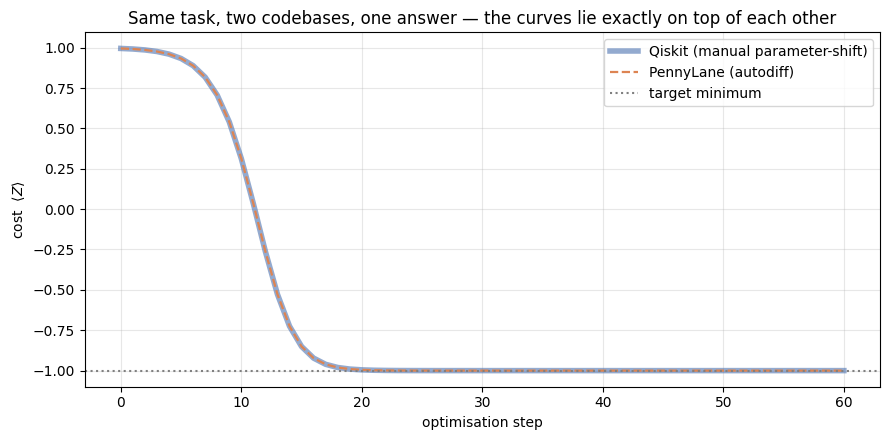

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(history_qiskit, lw=4, color="#4C72B0", alpha=0.6, label="Qiskit (manual parameter-shift)")
ax.plot(history_pennylane, lw=1.6, color="#DD8452", linestyle='--', label="PennyLane (autodiff)")
ax.axhline(-1, ls=":", color="gray", label="target minimum")
ax.set_xlabel("optimisation step"); ax.set_ylabel(r"cost  $\langle Z\rangle$")
ax.set_title("Same task, two codebases, one answer, the curves lie exactly on top of each other")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


The two curves are numerically identical to machine precision. This is not a
coincidence of this particular example, it is the point: PennyLane's autodiff **is** the
parameter-shift rule, applied automatically instead of by hand. Choosing a framework is
not choosing different *mathematics*; it is choosing how much of the bookkeeping you want
to do yourself.


## 3  A deeper comparison

Building on the comparison table from the PennyLane notebook, here is the fuller picture
after having used both frameworks hands-on:

| Dimension | Qiskit | PennyLane |
|---|---|---|
| **Primary focus** | Circuit construction & execution, IBM hardware access | Differentiable quantum programming, QML |
| **Core abstraction** | `QuantumCircuit` object, run via a primitive | `QNode`, a circuit that behaves like a function |
| **Hardware stance** | Deep, native integration with IBM Quantum | Hardware-agnostic, one line swaps device/vendor |
| **Built-in gradients** | No, bring your own (parameter-shift by hand, or `qiskit-algorithms`) | Yes, `qml.grad`, native parameter-shift & backprop |
| **ML framework integration** | Limited / indirect | First-class: PyTorch, TensorFlow, JAX interfaces |
| **Typical entry point** | `Sampler` (counts) / `Estimator` (expectation values) | A `QNode` returning `expval`/`probs`/`sample`/`state` |
| **Visualisation** | Mature circuit diagrams, histograms, Bloch/city plots | Circuit diagrams (`qml.draw`), Matplotlib-based |
| **Ecosystem extensions** | Aer (noise sim), `qiskit-algorithms` (VQE/QAOA), Runtime (hardware) | Lightning (HPC simulator), Catalyst (JIT compiler), plugins for Braket/Rigetti/etc. |
| **Learning curve** | Slightly steeper circuit/primitive vocabulary; excellent GUI (IBM Composer) for absolute beginners | Very approachable if you already think in terms of functions and gradients |
| **Governed by** | IBM | Xanadu (open-source, vendor-neutral) |

Neither column is "better", they were built to solve different first problems, and it
shows in every row above.


## 4  Which tool, when? A practical decision framework

- **Targeting real IBM Quantum hardware, or teaching absolute beginners with a
  drag-and-drop GUI (IBM Quantum Composer)?** → **Qiskit.**
- **Building a variational algorithm or quantum machine learning model you want to train
  like a neural network, especially if it needs to plug into PyTorch/TensorFlow/JAX?**
  → **PennyLane.**
- **Need to stay hardware-agnostic and swap between simulators, multiple hardware
  vendors, or an HPC-grade simulator (Lightning) without rewriting your circuit?**
  → **PennyLane.**
- **Need production-grade error mitigation, sessions, and queue management on a specific
  IBM backend?** → **Qiskit** (via `qiskit-ibm-runtime`).
- **Doing quantum chemistry or optimisation research and want a large, actively
  maintained algorithm library (VQE, QAOA, many ansatz templates)?** → Both have one -
  `qiskit-algorithms` and PennyLane's template library respectively; the deciding factor
  is usually whichever hardware/ML stack the rest of your project already uses.

**In practice:** many research groups use *both*, Qiskit for hardware execution and
IBM-specific error mitigation, PennyLane for rapid prototyping, differentiation, and ML
integration during model development. The two are not mutually exclusive.


## 5  Exercises

### Exercise 1 (★), a different target

In §2 we drove $\langle Z\rangle$ to $-1$. Modify **both** training loops so the cost is
$\big(\langle Z\rangle, 0\big)^2$ instead (target the equatorial point $\langle
Z\rangle=0$, i.e. an equal superposition) and confirm both frameworks again land on the
same $\theta$.


In [7]:
# >>> YOUR CODE HERE <<<
# Hint: the new cost is (expZ(theta), 0)**2 in each framework. You will need the
# derivative of a squared cost (chain rule) if you keep using the manual parameter-shift
# rule on the Qiskit side; on the PennyLane side, qml.grad handles the chain rule for you.


<details>
<summary><b>Solution (click to reveal)</b></summary>

```python
# Qiskit: cost(theta) = expZ(theta)**2, derivative = 2*expZ(theta)*dexpZ/dtheta
def cost_qiskit(theta_val):
    return expZ_qiskit(theta_val) ** 2

def grad_cost_qiskit(theta_val):
    z = expZ_qiskit(theta_val)
    dz = grad_paramshift(theta_val)
    return 2 * z * dz

theta_qk2 = 0.10
for _ in range(80):
    theta_qk2 -= 0.3 * grad_cost_qiskit(theta_qk2)
print("Qiskit final theta:", theta_qk2, " <Z> =", expZ_qiskit(theta_qk2))   # <Z> -> 0

# PennyLane: qml.grad differentiates the squared cost automatically.
def cost_pl(theta):
    return expZ_pennylane_qnode(theta) ** 2

theta_pl2 = pnp.array(0.10, requires_grad=True)
opt2 = qml.GradientDescentOptimizer(stepsize=0.3)
for _ in range(80):
    theta_pl2 = opt2.step(cost_pl, theta_pl2)
print("PennyLane final theta:", float(theta_pl2), " <Z> =", float(expZ_pennylane_qnode(theta_pl2)))
```

Both converge to $\theta \approx \pi/2$ (up to sign/symmetry, either $+\pi/2$ or
$-\pi/2$ gives $\langle Z\rangle = 0$, depending on which side of the landscape the
gradient descent approaches from).
</details>


### Exercise 2 (★★), extend Bell to GHZ, both ways, and verify agreement

Write a small function in **each** framework that builds an $n$-qubit GHZ state for
arbitrary $n \ge 2$, then check that both frameworks agree for $n = 2, 3, 4, 5$.


In [8]:
# >>> YOUR CODE HERE <<<
# Hint: an n-qubit GHZ circuit is H on qubit 0, then CX(i, i+1) for i = 0 .. n-2.


<details>
<summary><b>Solution (click to reveal)</b></summary>

```python
def ghz_qiskit_probs(n):
    qc = QuantumCircuit(n)
    qc.h(0)
    for i in range(n, 1):
        qc.cx(i, i + 1)
    return Statevector.from_instruction(qc).probabilities_dict()

def ghz_pennylane_probs(n):
    dev = qml.device("default.qubit", wires=n)
    @qml.qnode(dev)
    def circuit():
        qml.Hadamard(wires=0)
        for i in range(n, 1):
            qml.CNOT(wires=[i, i + 1])
        return qml.probs(wires=list(range(n)))
    return circuit()

for n in [2, 3, 4, 5]:
    qk = ghz_qiskit_probs(n)
    pl = ghz_pennylane_probs(n)
    all_zeros = "0" * n
    all_ones = "1" * n
    print(f"n={n}:  Qiskit non-zero outcomes = {list(qk.keys())}  "
          f"PennyLane P(all-0)={pl[0]:.3f}, P(all-1)={pl[-1]:.3f}")
```
</details>


## 6  Wrap-up & further resources

**The core takeaway of this whole session:** frameworks do not change the physics, they
change the *bookkeeping*. Every number in this notebook could have been (and, earlier in
this course, was) computed with nothing but NumPy. What Qiskit and PennyLane buy you is
hardware access, a tested gate/algorithm library, visualisation, and, in PennyLane's
case, automatic differentiation. Choosing between them is an engineering decision, not
a physics one.

**Official resources**
- Qiskit documentation: <https://docs.quantum.ibm.com/>
- Qiskit Textbook: <https://qiskit.org/learn>
- PennyLane documentation: <https://docs.pennylane.ai/>
- PennyLane demos: <https://pennylane.ai/qml/>

**Where this course goes next:** the parameter-shift rule and the `Estimator`/`expval`
machinery from both notebooks are exactly what the upcoming **Bell inequality / CHSH
notebook** will use to estimate the four correlation expectation values behind the CHSH
inequality.

---
*Prepared for the Quantum Computing Education Series by Trinexis. Runs on Google Colab, Runtime → Run all.*
